# Chapter 18: F vs B shipping capstone

The simulator runs in `generate.py` and saves to `data/ship_decisions.csv`. This notebook reads that file and lets the reader explore the cost regimes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from expkit.plot.style import apply_style, PALETTE
apply_style()

csv = Path('chapters/18-frequentist-vs-bayesian-shipping/data/ship_decisions.csv')
if not csv.exists():
    csv = Path('data/ship_decisions.csv')
df = pd.read_csv(csv)
print(f'loaded {len(df)} simulated experiments')

loaded 2000 simulated experiments


## Loop A: ship rate by true effect

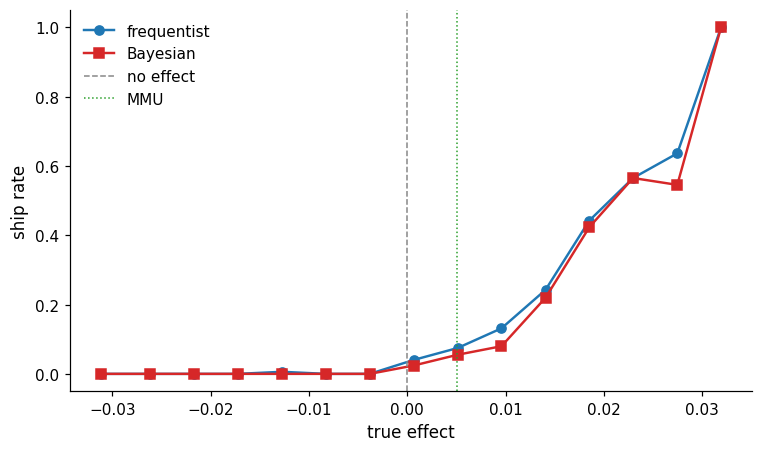

In [2]:
MMU = 0.005
bins = np.linspace(df['true_diff'].min(), df['true_diff'].max(), 16)
df['bin'] = pd.cut(df['true_diff'], bins=bins, include_lowest=True)
rates = df.groupby('bin', observed=True)[['f_ship', 'b_ship']].mean()
centers = [(b.left + b.right) / 2 for b in rates.index]
fig, ax = plt.subplots()
ax.plot(centers, rates['f_ship'], color=PALETTE['frequentist'], marker='o', label='frequentist')
ax.plot(centers, rates['b_ship'], color=PALETTE['bayesian'], marker='s', label='Bayesian')
ax.axvline(0, color=PALETTE['muted'], linestyle='--', linewidth=1, label='no effect')
ax.axvline(MMU, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='MMU')
ax.set_xlabel('true effect'); ax.set_ylabel('ship rate'); ax.legend(); plt.show()

## Loop B: confusion matrix

In [3]:
cm = df.groupby(['f_ship', 'b_ship']).size().unstack(fill_value=0)
cm = cm.reindex(index=[False, True], columns=[False, True], fill_value=0)
print('             B no-ship   B ship')
print(f'F no-ship      {cm.loc[False, False]:>6}     {cm.loc[False, True]:>6}')
print(f'F ship         {cm.loc[True, False]:>6}     {cm.loc[True, True]:>6}')
print()
agree = cm.loc[False, False] + cm.loc[True, True]
print(f'lenses agree on {agree}/{len(df)} = {100*agree/len(df):.1f}% of decisions')

             B no-ship   B ship
F no-ship        1855          0
F ship             29        116

lenses agree on 1971/2000 = 98.5% of decisions


## Loop C: cost regimes

Tune (FP cost, miss cost) and watch which lens has lower expected cost. Set MMU to whatever your stakeholders consider 'meaningful'.

In [4]:
def expected_cost(df, c_fp, c_miss, mmu=0.005):
    f_fp = ((df['f_ship'] == True) & (df['true_diff'] <= 0)).mean()
    f_miss = ((df['f_ship'] == False) & (df['true_diff'] > mmu)).mean()
    b_fp = ((df['b_ship'] == True) & (df['true_diff'] <= 0)).mean()
    b_miss = ((df['b_ship'] == False) & (df['true_diff'] > mmu)).mean()
    return c_fp * f_fp + c_miss * f_miss, c_fp * b_fp + c_miss * b_miss

for c_fp, c_miss in [(1.0, 1.0), (1.0, 5.0), (1.0, 10.0), (5.0, 1.0)]:
    f_cost, b_cost = expected_cost(df, c_fp, c_miss)
    winner = 'F' if f_cost < b_cost else 'B' if b_cost < f_cost else 'tie'
    print(f'C_fp={c_fp:>4}, C_miss={c_miss:>4}:  F cost={f_cost:.3f},  B cost={b_cost:.3f}  -> winner: {winner}')

C_fp= 1.0, C_miss= 1.0:  F cost=0.234,  B cost=0.241  -> winner: F
C_fp= 1.0, C_miss= 5.0:  F cost=1.160,  B cost=1.206  -> winner: F
C_fp= 1.0, C_miss=10.0:  F cost=2.317,  B cost=2.411  -> winner: F
C_fp= 5.0, C_miss= 1.0:  F cost=0.244,  B cost=0.243  -> winner: B


## Loop D: cost-ratio sweep

Hold C_fp = 1, sweep C_miss from 0.5 to 20. The lens with lower expected cost is the one to use under that risk profile.

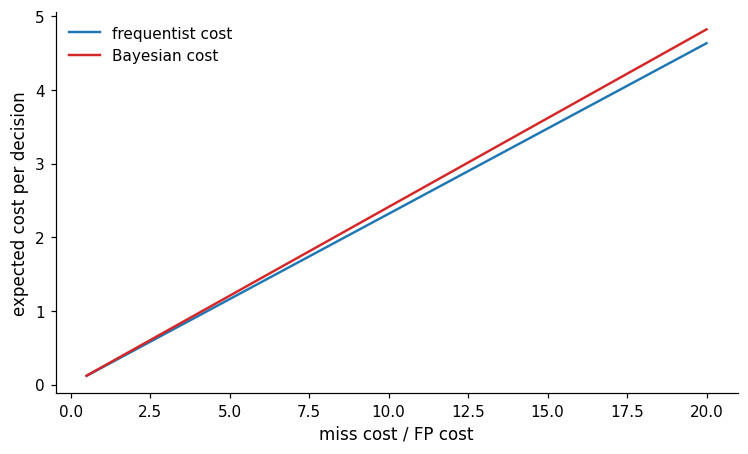

In [5]:
miss_costs = np.linspace(0.5, 20, 40)
f_costs = []; b_costs = []
for cm in miss_costs:
    f, b = expected_cost(df, 1.0, cm)
    f_costs.append(f); b_costs.append(b)
fig, ax = plt.subplots()
ax.plot(miss_costs, f_costs, color=PALETTE['frequentist'], label='frequentist cost')
ax.plot(miss_costs, b_costs, color=PALETTE['bayesian'], label='Bayesian cost')
ax.set_xlabel('miss cost / FP cost'); ax.set_ylabel('expected cost per decision'); ax.legend(); plt.show()

## Loop E: joint rule

Ship only if both lenses agree. Joint rate is more conservative than either alone.

In [6]:
df['joint_ship'] = df['f_ship'] & df['b_ship']
for lo, hi in [(-0.02, 0), (0, 0.005), (0.005, 0.01), (0.01, 0.02), (0.02, 0.05)]:
    sub = df[(df['true_diff'] > lo) & (df['true_diff'] <= hi)]
    print(f'true_diff in ({lo:+.3f}, {hi:+.3f}]  n={len(sub):>4}  F = {sub["f_ship"].mean():.2f}  B = {sub["b_ship"].mean():.2f}  joint = {sub["joint_ship"].mean():.2f}')

true_diff in (-0.020, +0.000]  n= 999  F = 0.01  B = 0.00  joint = 0.00
true_diff in (+0.000, +0.005]  n= 384  F = 0.05  B = 0.03  joint = 0.03
true_diff in (+0.005, +0.010]  n= 276  F = 0.11  B = 0.08  joint = 0.08
true_diff in (+0.010, +0.020]  n= 263  F = 0.24  B = 0.20  joint = 0.20
true_diff in (+0.020, +0.050]  n=  45  F = 0.62  B = 0.60  joint = 0.60
